# Model Development

## Objective

The objective of this notebook is to train, compare, and evaluate multiple machine learning classification models to predict the priority level of IT support tickets.

A baseline model is established first, followed by increasingly more complex algorithms. The best-performing model will be selected based on multiple evaluation metrics and saved for future inference.

In [28]:
# Standard libraries

import warnings
warnings.filterwarnings("ignore")

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

# Machine Learning
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from xgboost import XGBClassifier

import joblib

In [29]:
# Display options
pd.set_option("display.max_columns", None)

RANDOM_STATE = 42

# Load Processed Data

The preprocessed training and testing datasets generated in the previous notebook are loaded into memory. These datasets are ready for model training and evaluation.

In [30]:
# Load processed datasets
X_train = pd.read_csv("../data/processed/X_train.csv")
X_test = pd.read_csv("../data/processed/X_test.csv")

y_train = pd.read_csv("../data/processed/y_train.csv").squeeze("columns")
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze("columns")

In [31]:
print("=" * 60)
print("Datasets Loaded Successfully")
print("=" * 60)

print(f"X_train: {X_train.shape}")
print(f"X_test : {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test : {y_test.shape}")

Datasets Loaded Successfully
X_train: (40000, 49)
X_test : (10000, 49)
y_train: (40000,)
y_test : (10000,)


# Model Evaluation Function

A reusable function is created to ensure that every model is trained and evaluated using the exact same procedure and performance metrics.

This approach improves code readability, consistency, and maintainability while avoiding duplicated code.

In [32]:
import time

results = []
trained_models = {}

In [35]:
#MODEL EVALUATION FUNCTION

def evaluate_model(model, model_name):
    """
    Train and evaluate a classification model.

    Parameters
    ----------
    model : sklearn estimator
        Machine Learning model.

    model_name : str
        Name of the model.

    Returns
    -------
    dict
        Performance metrics.
    """

    start_time = time.time()

    # Train
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    training_time = time.time() - start_time

    metrics = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(
            y_test,
            y_pred,
            average="weighted"
        ),
        "Recall": recall_score(
            y_test,
            y_pred,
            average="weighted"
        ),
        "F1 Score": f1_score(
            y_test,
            y_pred,
            average="weighted"
        ),
        "Training Time (s)": training_time
    }

    results.append(metrics)

    trained_models[model_name] = model

    print("=" * 60)
    print(model_name)
    print("=" * 60)

    print("\nClassification Report\n")
    print(classification_report(y_test, y_pred))

    plt.figure(figsize=(6,5))

        # Confusion Matrix
    plt.figure(figsize=(7, 6))

    sns.heatmap(
        confusion_matrix(y_test, y_pred),
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Low", "Medium", "High"],
        yticklabels=["Low", "Medium", "High"]
    )

    plt.title(
        f"{model_name} - Confusion Matrix",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")

    plt.tight_layout()

    # Save only the XGBoost confusion matrix
    if model_name == "XGBoost":
        plt.savefig(
            "../reports/figures/xgboost_confusion_matrix.png",
            dpi=300,
            bbox_inches="tight"
        )

    plt.show()

    return metrics

# Baseline Model

Before training more sophisticated machine learning algorithms, a baseline model is established using a Dummy Classifier.

The Dummy Classifier always predicts the most frequent class and serves as a performance benchmark. Any predictive model should significantly outperform this baseline to demonstrate that it has learned meaningful patterns from the data.

DummyClassifier

Classification Report

              precision    recall  f1-score   support

           0       0.50      1.00      0.67      5000
           1       0.00      0.00      0.00      3500
           2       0.00      0.00      0.00      1500

    accuracy                           0.50     10000
   macro avg       0.17      0.33      0.22     10000
weighted avg       0.25      0.50      0.33     10000



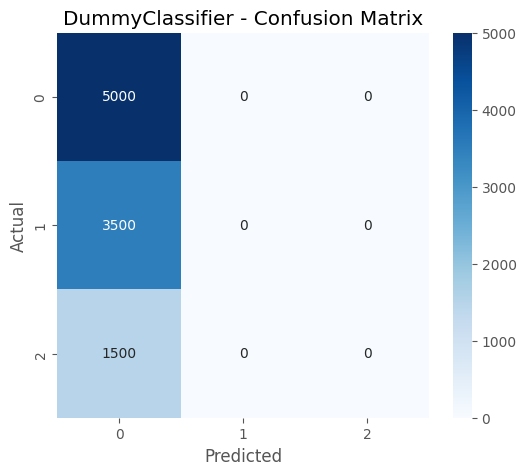

{'Model': 'DummyClassifier',
 'Accuracy': 0.5,
 'Precision': 0.25,
 'Recall': 0.5,
 'F1 Score': 0.3333333333333333,
 'Training Time (s)': 0.0025482177734375}

In [ ]:
baseline = DummyClassifier(
    strategy="most_frequent",
    random_state=RANDOM_STATE
)

evaluate_model(
    baseline,
    "DummyClassifier"
)

# Logistic Regression

Logistic Regression is used as the first real predictive model.

Although it is a linear algorithm, it often provides a strong baseline for classification tasks and offers high interpretability.

Logistic Regression

Classification Report

              precision    recall  f1-score   support

           0       0.91      0.93      0.92      5000
           1       0.80      0.81      0.81      3500
           2       0.85      0.77      0.81      1500

    accuracy                           0.86     10000
   macro avg       0.85      0.83      0.84     10000
weighted avg       0.86      0.86      0.86     10000



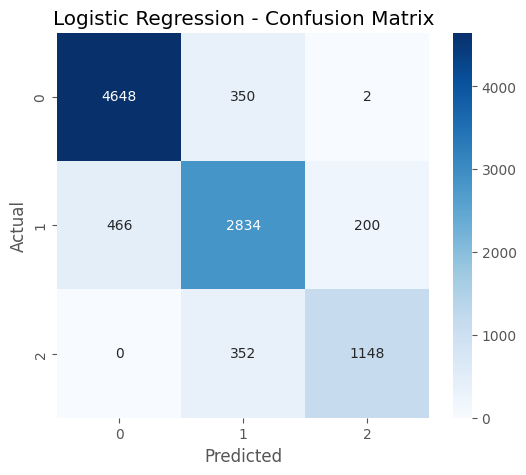

{'Model': 'Logistic Regression',
 'Accuracy': 0.863,
 'Precision': 0.8625090569013423,
 'Recall': 0.863,
 'F1 Score': 0.8623530813860673,
 'Training Time (s)': 0.21680903434753418}

In [ ]:
logistic_model = LogisticRegression(
    random_state=RANDOM_STATE,
    max_iter=1000
)

evaluate_model(
    logistic_model,
    "Logistic Regression"
)

# Decision Tree

Decision Trees can capture non-linear relationships and interactions between features.

They are easy to interpret and provide a useful comparison against linear models.

Decision Tree

Classification Report

              precision    recall  f1-score   support

           0       0.95      0.95      0.95      5000
           1       0.87      0.90      0.88      3500
           2       0.91      0.84      0.87      1500

    accuracy                           0.92     10000
   macro avg       0.91      0.90      0.90     10000
weighted avg       0.92      0.92      0.92     10000



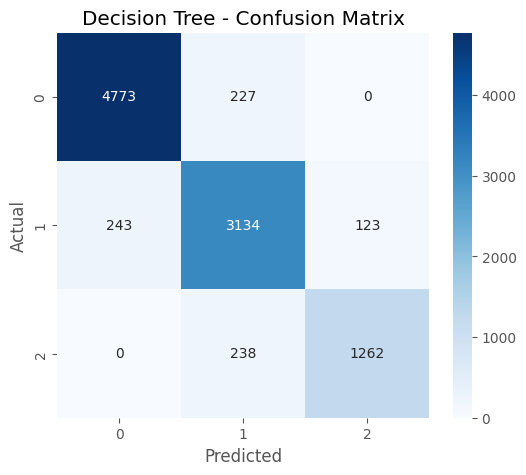

{'Model': 'Decision Tree',
 'Accuracy': 0.9169,
 'Precision': 0.9172353176297631,
 'Recall': 0.9169,
 'F1 Score': 0.9167974833020608,
 'Training Time (s)': 0.13184595108032227}

In [ ]:
decision_tree = DecisionTreeClassifier(
    random_state=RANDOM_STATE,
    max_depth=10
)

evaluate_model(
    decision_tree,
    "Decision Tree"
)

# Random Forest

Random Forest combines multiple decision trees to improve predictive performance and reduce overfitting.

It is one of the most widely used ensemble methods for structured tabular datasets.

Random Forest

Classification Report

              precision    recall  f1-score   support

           0       0.95      0.96      0.96      5000
           1       0.88      0.91      0.90      3500
           2       0.96      0.84      0.89      1500

    accuracy                           0.93     10000
   macro avg       0.93      0.91      0.92     10000
weighted avg       0.93      0.93      0.93     10000



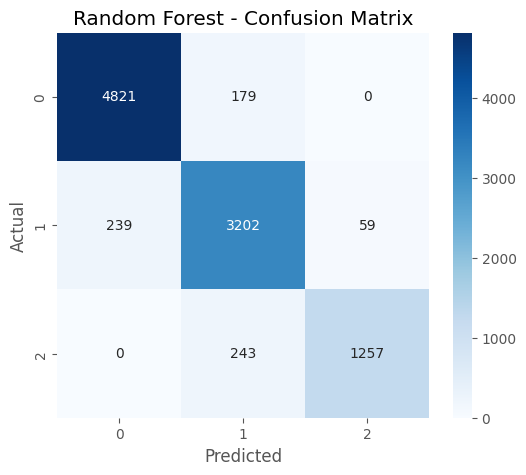

{'Model': 'Random Forest',
 'Accuracy': 0.928,
 'Precision': 0.9289024045571516,
 'Recall': 0.928,
 'F1 Score': 0.9277646186218531,
 'Training Time (s)': 0.6704487800598145}

In [ ]:
random_forest = RandomForestClassifier(
    n_estimators=200,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

evaluate_model(
    random_forest,
    "Random Forest"
)

# XGBoost

XGBoost is a gradient boosting algorithm widely recognized for its excellent performance on structured tabular datasets.

It builds an ensemble of decision trees sequentially, where each tree attempts to correct the errors made by the previous ones.

XGBoost

Classification Report

              precision    recall  f1-score   support

           0       0.98      0.98      0.98      5000
           1       0.95      0.96      0.96      3500
           2       0.97      0.94      0.96      1500

    accuracy                           0.97     10000
   macro avg       0.97      0.96      0.97     10000
weighted avg       0.97      0.97      0.97     10000



<Figure size 600x500 with 0 Axes>

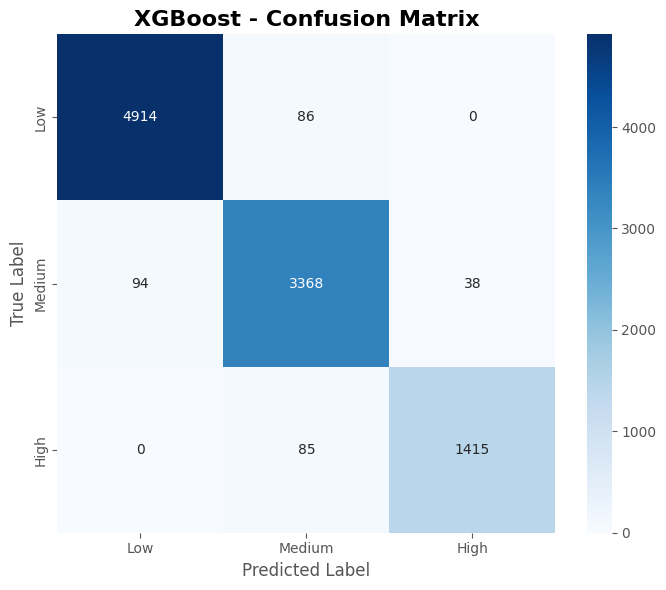

{'Model': 'XGBoost',
 'Accuracy': 0.9697,
 'Precision': 0.9697805409369714,
 'Recall': 0.9697,
 'F1 Score': 0.9696932502163476,
 'Training Time (s)': 1.0870299339294434}

In [36]:
xgb_model = XGBClassifier(
    random_state=RANDOM_STATE,
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    objective='multi:softprob',
    num_class=3,
    eval_metric="mlogloss"
)

evaluate_model(
    xgb_model,
    "XGBoost"
)

In [ ]:
#Creation of Table to compare the performance of the models

results_df = (
    pd.DataFrame(results)
    .sort_values(
        by="F1 Score",
        ascending=False
    )
    .reset_index(drop=True)
)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,Training Time (s)
0,XGBoost,0.9697,0.969781,0.9697,0.969693,1.068473
1,Random Forest,0.9280,0.928902,0.9280,0.927765,0.670449
2,Decision Tree,0.9169,0.917235,0.9169,0.916797,0.131846
3,Logistic Regression,0.8630,0.862509,0.8630,0.862353,0.216809
4,DummyClassifier,0.5000,0.250000,0.5000,0.333333,0.002548


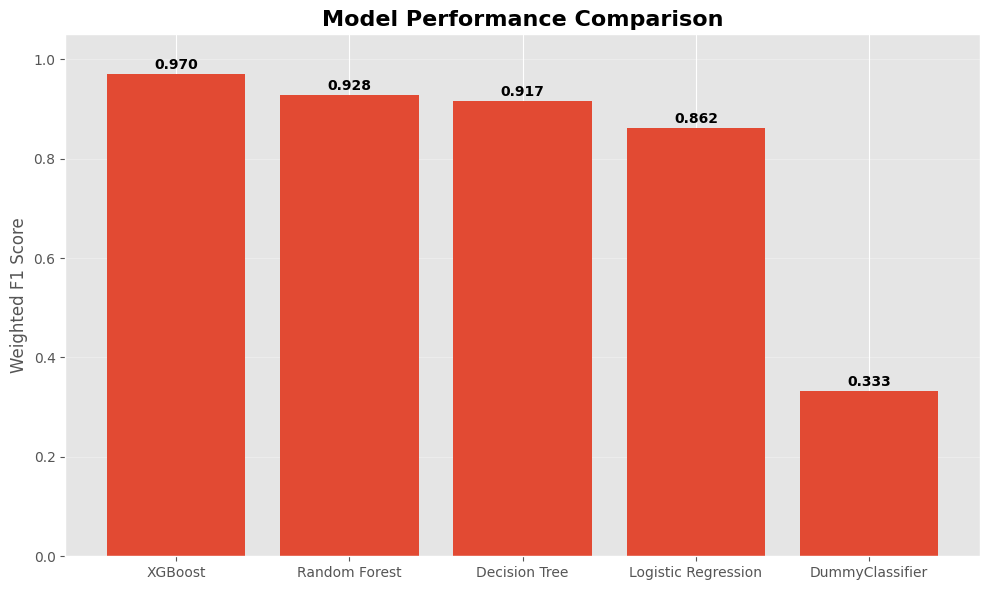

In [ ]:
#Graphic of Comparison

# Model Performance Comparison

import matplotlib.pyplot as plt

# Order models from best to worst
plot_df = results_df.sort_values("F1 Score", ascending=False)

plt.figure(figsize=(10, 6))

bars = plt.bar(
    plot_df["Model"],
    plot_df["F1 Score"]
)

# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.01,
        f"{height:.3f}",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

plt.ylim(0, 1.05)

plt.ylabel("Weighted F1 Score")
plt.xlabel("")
plt.title("Model Performance Comparison", fontsize=16, fontweight="bold")

plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

# Save BEFORE showing
plt.savefig(
    "../reports/figures/model_performance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Feature Importance

Feature importance measures the contribution of each feature to the model's predictions.

Understanding which variables have the greatest influence helps explain the model's behavior and provides valuable business insights into the factors that drive ticket priority.

In [ ]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb_model.feature_importances_
})

feature_importance = (
    feature_importance
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

feature_importance.head(15)

,Feature,Importance
0,customers_affected,0.169746
1,downtime_min,0.114684
2,customer_tier,0.081562
3,reported_by_role_c_level,0.063547
4,product_area_auth,0.053622
5,error_rate_pct,0.051342
6,product_area_data_pipeline,0.047676
7,product_area_analytics,0.045635
8,payment_impact_flag,0.042496
9,has_runbook,0.037269


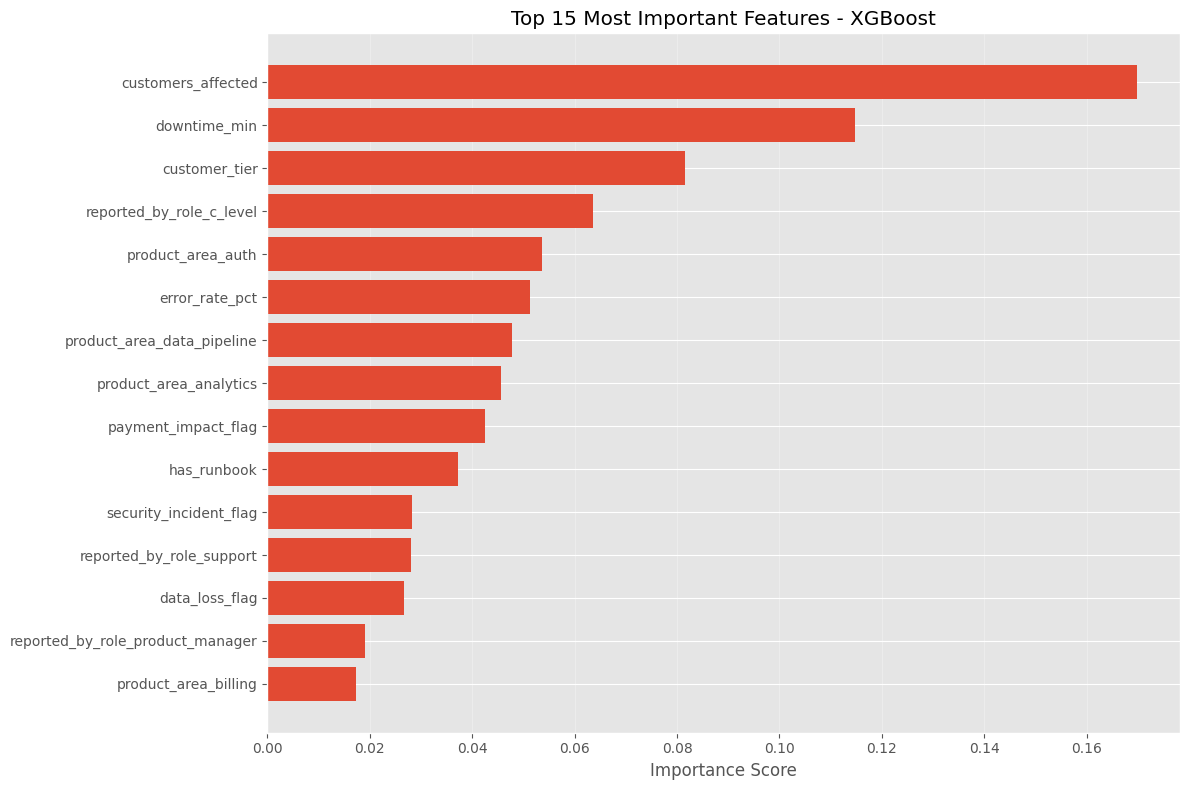

In [ ]:
#Visualization

# Visualization

plt.figure(figsize=(12, 8))

top_features = feature_importance.head(15)

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.gca().invert_yaxis()

plt.grid(axis="x", alpha=0.3)

plt.xlabel("Importance Score")
plt.ylabel("")
plt.title("Top 15 Most Important Features - XGBoost")

plt.tight_layout()

# Save BEFORE showing
plt.savefig(
    "../reports/figures/feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
#Cumulative Importance

feature_importance["Cumulative Importance"] = (
    feature_importance["Importance"].cumsum()
)

feature_importance.head(15)

,Feature,Importance,Cumulative Importance
0,customers_affected,0.169746,0.169746
1,downtime_min,0.114684,0.284430
2,customer_tier,0.081562,0.365992
3,reported_by_role_c_level,0.063547,0.429539
4,product_area_auth,0.053622,0.483162
5,error_rate_pct,0.051342,0.534504
6,product_area_data_pipeline,0.047676,0.582179
7,product_area_analytics,0.045635,0.627815
8,payment_impact_flag,0.042496,0.670311
9,has_runbook,0.037269,0.707580


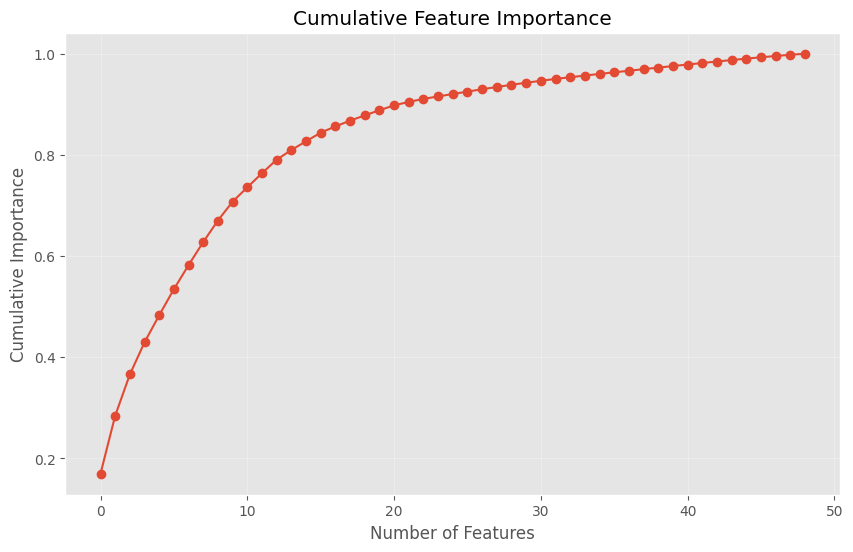

In [ ]:
plt.figure(figsize=(10,6))

plt.plot(
    feature_importance["Cumulative Importance"],
    marker="o"
)

plt.grid(alpha=0.3)

plt.xlabel("Number of Features")

plt.ylabel("Cumulative Importance")

plt.title("Cumulative Feature Importance")

plt.show()

In [ ]:
#Top10
top10 = feature_importance.head(10)

display(top10)

,Feature,Importance,Cumulative Importance
0,customers_affected,0.169746,0.169746
1,downtime_min,0.114684,0.284430
2,customer_tier,0.081562,0.365992
3,reported_by_role_c_level,0.063547,0.429539
4,product_area_auth,0.053622,0.483162
5,error_rate_pct,0.051342,0.534504
6,product_area_data_pipeline,0.047676,0.582179
7,product_area_analytics,0.045635,0.627815
8,payment_impact_flag,0.042496,0.670311
9,has_runbook,0.037269,0.707580


## Feature Importance Interpretation

The XGBoost model assigns different importance scores to each feature based on its contribution to predicting ticket priority.

The most influential variables indicate the operational factors that have the greatest impact on whether a support ticket is classified as low, medium, or high priority.

These insights improve model interpretability and can also help support teams identify the key characteristics associated with critical incidents.

## Business Interpretation

The feature importance analysis shows that the model primarily relies on variables representing business impact and operational severity.

The number of affected customers (`customers_affected`) and service downtime (`downtime_min`) are the strongest predictors of ticket priority, followed by customer tier and the role of the person reporting the incident.

Operational indicators such as payment impact, security incidents, error rate, and data loss also contribute significantly to the model's decisions.

Overall, the model demonstrates that ticket priority is driven mainly by operational impact rather than organizational metadata, making its predictions consistent with real-world IT support practices.

In [ ]:
joblib.dump(
    trained_models["XGBoost"],
    "../models/xgboost_model.pkl"
)

['../models/xgboost_model.pkl']